# M4A2 - GANs

Na prática de hoje vamos treinar um modelo do tipo GAN utilizando [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Treinar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [8]:
%pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Importar as bibliotecas e Ler Imagens do Disco

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [10]:
batch_size = 100

# MNIST Dataset.
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset = torchvision.datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
# Data Loader.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

## Treinar Modelo

Agora vamos criar os modelos e treinar ele.

In [11]:
########################
## Criando os modelos ##
########################


# Gerador.
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()       
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)
    
    # método forward. 
    def forward(self, x): 
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))

# Discrimador.
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)
    
    # método forward. 
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [12]:
# Instanciar as redes.
z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

In [13]:
# Função de perda.
criterion = torch.nn.BCELoss() 

# Otimizador.
lr = 0.0002 
G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)


In [14]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()
        
    return  D_loss.data.item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()
        
    return G_loss.data.item()

In [17]:
# Laço de treino.
n_epoch = 10
for epoch in range(1, n_epoch+1):           
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

[1/10]: loss_d: 0.768, loss_g: 1.914
[2/10]: loss_d: 0.834, loss_g: 1.782
[3/10]: loss_d: 0.892, loss_g: 1.644
[4/10]: loss_d: 0.871, loss_g: 1.735
[5/10]: loss_d: 0.930, loss_g: 1.573
[6/10]: loss_d: 0.877, loss_g: 1.655
[7/10]: loss_d: 0.879, loss_g: 1.668
[8/10]: loss_d: 0.909, loss_g: 1.615
[9/10]: loss_d: 0.914, loss_g: 1.572
[10/10]: loss_d: 0.919, loss_g: 1.585


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


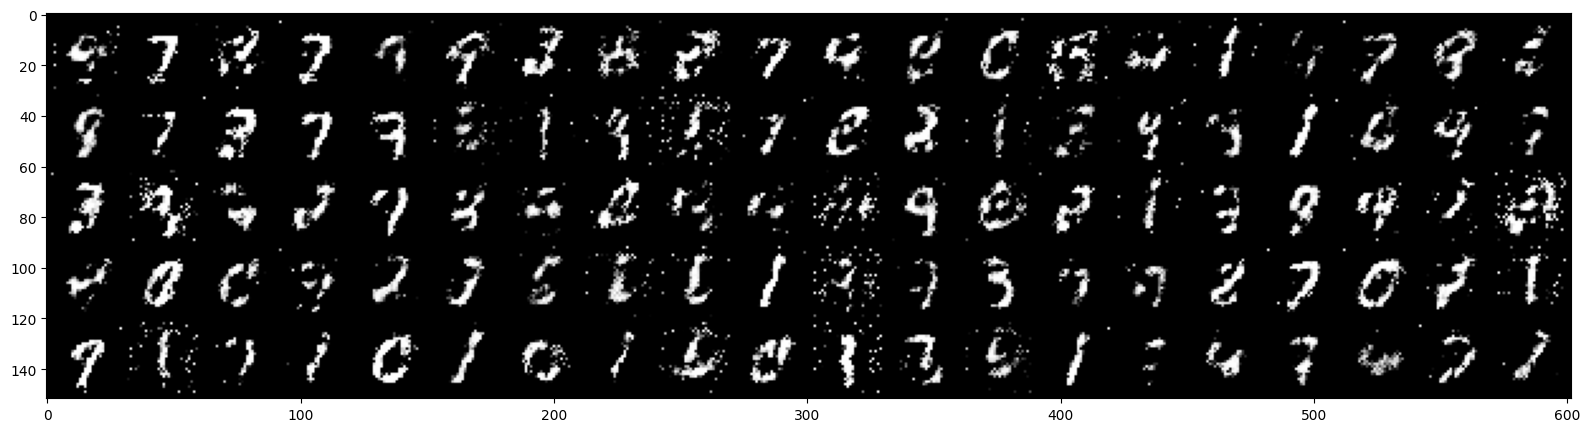

In [18]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')


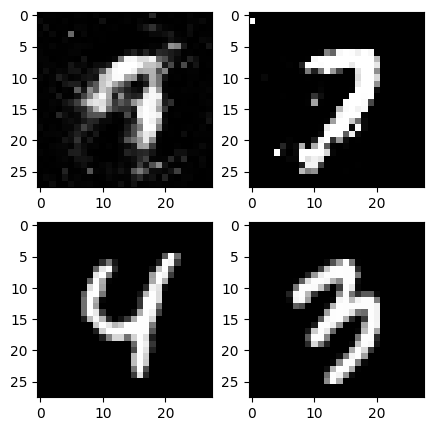

In [22]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[0]].transpose(1, 2, 0), cmap="gray")
axes[0, 1].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[1]].transpose(1, 2, 0), cmap="gray")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].numpy().transpose(1,2,0), cmap="gray")

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/lyeoni/pytorch-mnist-GAN
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente alterar a base de dados e veja se o modelo continua funcionando?
- [ ] Tente alterar alguns hiperparâmetros de treinamento, como learning rate, batch, e veja como isso altera os resultados.